# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [1]:
ПІБ = 'Хвостова Олександра'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-32'      # напр. 'КН-31'
ВАРІАНТ = 12     # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [2]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Хвостова Олександра, ШІ-32, варіант 12
ваш потік:                   P>100
ваша пара для графіка 3:     густина вітру та потік P>1
ваш агрегат для етапу 4:     максимум
ваше додаткове питання:      Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [4]:
df = pd.read_excel(ФАЙЛ)
display(df.head())
df.info()

,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 7225 entries, 0 to 7224
Data columns (total 32 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Unnamed: 0                                   0 non-null      float64
 1   ftp://ftp.swpc.noaa.gov/pub/lists/particle/  7222 non-null   object 
 2   Unnamed: 2                                   7202 non-null   object 
 3   Unnamed: 3                                   7202 non-null   object 
 4   Unnamed: 4                                   7202 non-null   object 
 5   Unnamed: 5                                   7203 non-null   object 
 6   Unnamed: 6                                   7203 non-null   object 
 7   Unnamed: 7                                   7198 non-null   object 
 8   Unnamed: 8                                   7198 non-null   object 
 9   Unnamed: 9                                   7198 non-null   object 
 10  Unnamed: 10

**Відповідь 1.1:** *(чому звичайне читання дало саме такий результат)*

Pandas сприйняв найперший рядок за назви стовпців (звідси посилання та Unnamed). 
Оскільки в одному стовпці опиняються і текст, і числа, pandas не може визначити єдиний числовий тип і ставить *object*.

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [5]:
RAW = pd.read_excel(ФАЙЛ, header=None)
print(f"Розмір таблиці: {RAW.shape}")
RAW.head(30)

Розмір таблиці: (7226, 32)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [6]:
counts = RAW.notna().sum()
display(counts)

0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64

**Відповідь 1.3:** *(скільки таблиць і які стовпці кожна займає)*

3 таблиці:
1 таблиця - 1-14 стовпці, 2 таблиця - 16-19 стовпці, 3 таблиця - 24-31 стовпці

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [7]:
print('--- Таблиця A ---')
for i in range(0, 22):
    v = RAW.iloc[i, 1]
    if pd.notna(v): print(v)

print('\n--- Таблиця B  ---')
for i in range(0, 26):
    v = RAW.iloc[i, 16]
    if pd.notna(v): print(v)

print('\n--- Таблиця C ---')
for i in range(0, 26):
    v = RAW.iloc[i, 26]
    if pd.notna(v): print(v)

--- Таблиця A ---
ftp://ftp.swpc.noaa.gov/pub/lists/particle/
:Data_list: 20170901_Gs_part_5m.txt
:Created: 2017 Sep 02 0011 UTC
# Prepared by the U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center
# Please send comments and suggestions to SWPC.Webmaster@noaa.gov 
# 
# Label: P > 1 = Particles at >1 Mev
# Label: P > 5 = Particles at >5 Mev
# Label: P >10 = Particles at >10 Mev
# Label: P >30 = Particles at >30 Mev
# Label: P >50 = Particles at >50 Mev
# Label: P>100 = Particles at >100 Mev
# Label: E>0.8 = Electrons at >0.8 Mev
# Label: E>2.0 = Electrons at >2.0 Mev
# Label: E>4.0 = Electrons at >4.0 Mev
# Units: Particles = Protons/cm2-s-sr
# Units: Electrons = Electrons/cm2-s-sr
# Source: GOES-15
# Location: W135
# Missing data: -1.00e+05

--- Таблиця B  ---
ftp://ftp.swpc.noaa.gov/pub/indices/old_indices/2017Q3_DSD.txt
Product: Daily Solar Data         quar_DSD.txt
:Issued: 0825 UT 04 Oct 2017
#
#  Prepared by the U.S. Dept. of Commerce, NOAA, Space Weather Prediction Cen

**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A | NOAA, Space Weather Prediction Center *ftp://ftp.swpc.noaa.gov/pub/lists/particle/* | Particles = Protons/cm2-s-sr; Electrons = Electrons/cm2-s-sr, пропуски позначені кодом `-1.00e+05` |
| B | NOAA, Space Weather Prediction Center *ftp://ftp.swpc.noaa.gov/pub/indices/old_indices/2017Q3_DSD.txt* | радіопотік F10.7, стандартні одиниці сонячного потоку (10⁻²² Вт·м⁻²·Гц⁻¹) |
| C | SOHO CELIAS Proton Monitor *http://umtof.umd.edu/pm/crn/* | Proton speed [km/sec], Proton density [protons per cubic centimeter], пропуски позначені кодом `-1` |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [8]:
A = RAW.iloc[26:26+7200, 1:15].copy()
A.columns = ['YR', 'MO', 'DA', 'HHMM', 'Julian_Day', 'Sec_of_Day',
             'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']
A = A.apply(pd.to_numeric, errors='coerce')

B = RAW.iloc[27:27+25, 16:20].copy()
B.columns = ['YR', 'MO', 'DA', 'F10.7']
B = B.apply(pd.to_numeric, errors='coerce')

C = RAW.iloc[27:27+601, 24:32].copy()
C.columns = ['idx1', 'idx2', 'YR', 'MO', 'DA', 'HH', 'швидкість вітру', 'густина вітру']
C = C.drop(columns=['idx1', 'idx2'])
C = C.apply(pd.to_numeric, errors='coerce')

for name, df in [('A', A), ('B', B), ('C', C)]:
    print(name, df.shape)

display(A.head())
display(B.head())
display(C.head())

A (7200, 14)
B (25, 4)
C (601, 6)


,YR,MO,DA,HHMM,Julian_Day,Sec_of_Day,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0
26,2017,8,28,0,57993,0,12.00,0.260,0.180,0.1140,0.1040,0.0793,23600.0,1180.0
27,2017,8,28,5,57993,300,19.40,0.690,0.314,0.1120,0.0612,0.0251,23100.0,1160.0
28,2017,8,28,10,57993,600,8.48,0.168,0.130,0.0717,0.0614,0.0304,22200.0,1090.0
29,2017,8,28,15,57993,900,15.40,0.566,0.198,0.0926,0.0568,0.0251,20400.0,997.0
30,2017,8,28,20,57993,1200,6.41,0.156,0.118,0.0597,0.0494,0.0251,18500.0,875.0


,YR,MO,DA,F10.7
27,2017,8,28,82
28,2017,8,29,84
29,2017,8,30,87
30,2017,8,31,92
31,2017,9,1,93


,YR,MO,DA,HH,швидкість вітру,густина вітру
27,17,8,28,0,285,3.0
28,17,8,28,1,305,3.4
29,17,8,28,2,309,1.7
30,17,8,28,3,304,2.0
31,17,8,28,4,302,2.3


### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [9]:
A['ts'] = pd.to_datetime(dict(
    year=A['YR'], month=A['MO'], day=A['DA'],
    hour=(A['HHMM'] // 100).astype(int),
    minute=(A['HHMM'] % 100).astype(int)))

B['ts'] = pd.to_datetime(dict(year=B['YR'], month=B['MO'], day=B['DA']))

C['ts'] = pd.to_datetime(dict(
    year=C['YR'] + 2000, month=C['MO'], day=C['DA'], hour=C['HH']))

for name, df in [('A', A), ('B', B), ('C', C)]:
    print(f"{name}: {df['ts'].min()}  —  {df['ts'].max()}")

A: 2017-08-28 00:00:00  —  2017-09-21 23:55:00
B: 2017-08-28 00:00:00  —  2017-09-21 00:00:00
C: 2017-08-28 00:00:00  —  2017-09-22 00:00:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [10]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [11]:
for name, df in [('A', A), ('B', B), ('C', C)]:
    print(f"{name}")
    print('розмір:', df.shape)
    print('\nтипи стовпців:')
    print(df.dtypes)
    print('\nпропуски по стовпцях:')
    print(df.isna().sum())
    print('\nповних дублікатів рядків:', df.duplicated().sum())
    print('\nописові статистики:')
    display(df.describe())
    print()

A
розмір: (7200, 15)

типи стовпців:
YR                     int64
MO                     int64
DA                     int64
HHMM                   int64
Julian_Day             int64
Sec_of_Day             int64
P>1                  float64
P>5                  float64
P>10                 float64
P>30                 float64
P>50                 float64
P>100                float64
E>0.8                float64
E>2.0                float64
ts            datetime64[us]
dtype: object

пропуски по стовпцях:
YR            0
MO            0
DA            0
HHMM          0
Julian_Day    0
Sec_of_Day    0
P>1           3
P>5           3
P>10          3
P>30          3
P>50          3
P>100         3
E>0.8         3
E>2.0         3
ts            0
dtype: int64

повних дублікатів рядків: 0

описові статистики:


,YR,MO,DA,HHMM,Julian_Day,Sec_of_Day,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0,ts
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.00000,7197.000000,7197.000000,7200
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000,689.325064,156.626057,76.474020,18.838604,7.446840,1.65929,81862.741801,11401.502123,2017-09-09 11:57:30
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000,0.429000,0.151000,0.117000,0.057600,0.045500,0.02240,4.300000,0.133000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000,11.700000,0.279000,0.186000,0.098400,0.059700,0.02630,22200.000000,552.000000,2017-09-03 05:58:45
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,68600.000000,4290.000000,2017-09-09 11:57:30
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000,560.000000,107.000000,35.800000,0.990000,0.249000,0.06700,143000.000000,14100.000000,2017-09-15 17:56:15
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000,32500.000000,2890.000000,1330.000000,399.000000,191.000000,61.50000,259000.000000,110000.000000,2017-09-21 23:55:00
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,65728.005824,16920.617446,NaN



B
розмір: (25, 5)

типи стовпців:
YR                int64
MO                int64
DA                int64
F10.7             int64
ts       datetime64[us]
dtype: object

пропуски по стовпцях:
YR       0
MO       0
DA       0
F10.7    0
ts       0
dtype: int64

повних дублікатів рядків: 0

описові статистики:


,YR,MO,DA,F10.7,ts
count,25.0,25.000000,25.000000,25.000000,25
mean,2017.0,8.840000,13.960000,92.680000,2017-09-09 00:00:00
min,2017.0,8.000000,1.000000,71.000000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,74.000000,2017-09-03 00:00:00
50%,2017.0,9.000000,13.000000,84.000000,2017-09-09 00:00:00
75%,2017.0,9.000000,19.000000,107.000000,2017-09-15 00:00:00
max,2017.0,9.000000,31.000000,140.000000,2017-09-21 00:00:00
std,0.0,0.374166,8.955817,22.206831,NaN



C
розмір: (601, 7)

типи стовпців:
YR                          int64
MO                          int64
DA                          int64
HH                          int64
швидкість вітру             int64
густина вітру             float64
ts                 datetime64[us]
dtype: object

пропуски по стовпцях:
YR                 0
MO                 0
DA                 0
HH                 0
швидкість вітру    0
густина вітру      0
ts                 0
dtype: int64

повних дублікатів рядків: 0

описові статистики:


,YR,MO,DA,HH,швидкість вітру,густина вітру,ts
count,601.0,601.000000,601.000000,601.000000,601.000000,601.000000,601
mean,17.0,8.840266,13.973378,11.480865,506.547421,2.907654,2017-09-09 12:00:00
min,17.0,8.000000,1.000000,0.000000,-1.000000,-1.000000,2017-08-28 00:00:00
25%,17.0,9.000000,7.000000,5.000000,447.000000,1.800000,2017-09-03 06:00:00
50%,17.0,9.000000,13.000000,11.000000,517.000000,2.400000,2017-09-09 12:00:00
75%,17.0,9.000000,19.000000,17.000000,584.000000,3.400000,2017-09-15 18:00:00
max,17.0,9.000000,31.000000,23.000000,806.000000,31.700000,2017-09-22 00:00:00
std,0.0,0.366664,8.781000,6.938063,125.073291,2.637873,NaN


### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [12]:
print('від\'ємних значень швидкості:', (C['швидкість вітру'] < 0).sum())
print('від\'ємних значень густини:  ', (C['густина вітру'] < 0).sum())

print('\nдо заміни:')
print('швидкість — середнє: %.2f, мінімум: %.2f' % (C['швидкість вітру'].mean(), C['швидкість вітру'].min()))
print('густина   — середнє: %.2f, мінімум: %.2f' % (C['густина вітру'].mean(), C['густина вітру'].min()))

C.loc[C['швидкість вітру'] < 0, 'швидкість вітру'] = np.nan
C.loc[C['густина вітру'] < 0, 'густина вітру'] = np.nan

print('\nпісля заміни:')
print('швидкість — середнє: %.2f, мінімум: %.2f' % (C['швидкість вітру'].mean(), C['швидкість вітру'].min()))
print('густина   — середнє: %.2f, мінімум: %.2f' % (C['густина вітру'].mean(), C['густина вітру'].min()))

від'ємних значень швидкості: 8
від'ємних значень густини:   8

до заміни:
швидкість — середнє: 506.55, мінімум: -1.00
густина   — середнє: 2.91, мінімум: -1.00

після заміни:
швидкість — середнє: 513.39, мінімум: 277.00
густина   — середнє: 2.96, мінімум: 0.10


**Відповідь 3.2:** *(що це за значення, скільки їх, як вони спотворювали середнє)*

`-1` - це службовий код відсутності вимірювання, який використовує SOHO CELIAS
Proton Monitor. У стовпцях «швидкість вітру» і «густина вітру» таких значень по 8 у кожному.
Оскільки фізична швидкість і густина не можуть бути від'ємними, `-1` штучно занижував середнє - особливо для густини, де реальні значення малі (від 0.1 до кількох десятків см⁻³) і одне значення

`-1` має відносно великий вплив. Після заміни на `NaN` середня швидкість зросла з 506.5 до 513.4 км/с, середня густина - з 2.91 до 2.96 см⁻³, а мінімум перестав бути фізично неможливим і став 277 км/с та 0.1 см⁻³ відповідно.

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [13]:
display(A[['YR', 'MO', 'DA', 'HHMM', 'Julian_Day', 'Sec_of_Day']].describe())

,YR,MO,DA,HHMM,Julian_Day,Sec_of_Day
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000


**Відповідь 3.3:** *(які це стовпці та чому середнє для них не має сенсу)*

Це стовпці `YR`, `MO`, `DA`, `HHMM`, `Julian_Day`, `Sec_of_Day`. Жоден з них не є результатом вимірювання - усі це компоненти часової мітки. 

`YR` однакове для всіх рядків (2017), тож його «середнє» взагалі не несе інформації. `MO`, `DA` - номер місяця й дня в місяці, `HHMM` - час у форматі «година·100 + хвилина» (циклічна величина: 23:55 записано як 2355, а не як число, близьке до 0000), `Julian_Day` і `Sec_of_Day` - зростаючі лічильники в межах доби/року. 

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [14]:
flux_cols = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

A_idx = A.set_index('ts')
A_hourly = A_idx[flux_cols].resample('h').agg(['mean', 'max'])
A_hourly.columns = [f'{col}_{stat}' for col, stat in A_hourly.columns]
A_hourly = A_hourly.reset_index()

print(A_hourly.shape)
A_hourly.head()

(600, 17)


,ts,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max
0,2017-08-28 00:00:00,9.778333,19.40,0.324917,0.690,0.192917,0.314,0.098850,0.2240,0.077583,0.1780,0.040692,0.0793,20941.666667,23600.0,1011.583333,1180.0
1,2017-08-28 01:00:00,7.994167,13.60,0.291667,0.512,0.156583,0.259,0.072583,0.0919,0.058700,0.0798,0.029950,0.0471,18091.666667,20600.0,713.000000,907.0
2,2017-08-28 02:00:00,6.099167,10.80,0.283000,0.479,0.177667,0.321,0.084450,0.1210,0.069642,0.1110,0.035025,0.0595,14108.333333,15000.0,380.833333,475.0
3,2017-08-28 03:00:00,4.752500,7.76,0.236833,0.329,0.166333,0.244,0.087658,0.1800,0.068092,0.1390,0.035517,0.0818,12766.666667,13100.0,267.916667,284.0
4,2017-08-28 04:00:00,4.158333,6.62,0.334917,0.539,0.208333,0.309,0.084800,0.1530,0.072850,0.1420,0.039708,0.0694,11333.333333,12300.0,203.000000,234.0


### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

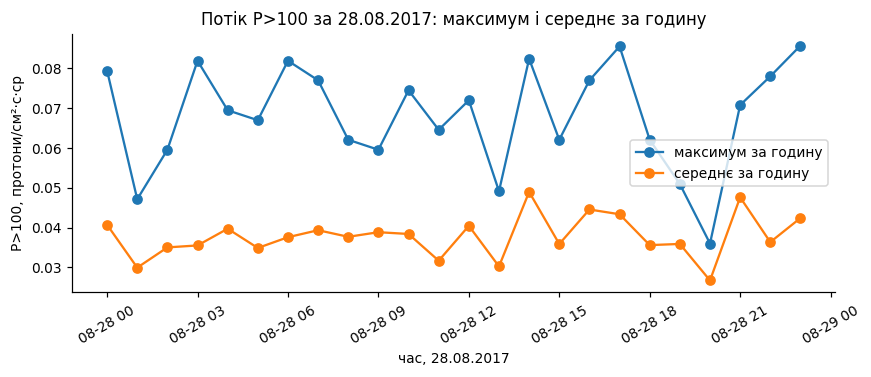

In [15]:
date = A[(A['ts'] >= '2017-08-28') & (A['ts'] < '2017-08-29')].set_index('ts')

p_max = date['P>100'].resample('h').max()
p_mean = date['P>100'].resample('h').mean()

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(p_max.index, p_max.values, marker='o', label='максимум за годину')
ax.plot(p_mean.index, p_mean.values, marker='o', label='середнє за годину')
ax.set_xlabel('час, 28.08.2017')
ax.set_ylabel('P>100, протони/см²·с·ср')
ax.set_title('Потік P>100 за 28.08.2017: максимум і середнє за годину')
ax.legend()
ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()

**Відповідь 4.2:** *(чим відрізняються криві та коли це важливо)*

Крива максимуму (синя): показує найвищий піковий сплеск потоку у межах кожної окремої години. Вона має високу амплітуду коливань і чутлива до точкових сплесків.

Крива середнього (помаранчева): показує середній рівень радіаційного потоку за годину. Вона має згладжену траєкторію.

Для оцінки загальної накопиченої дози радіації за тривалий час орієнтуються на середнє значення (mean). Для оцінки критичних пікових перевантажень орієнтуються на максимум (max), оскільки навіть один імпульсний сплеск вище норми може вивести з ладу обладнання або спричинити збій у пам'яті.

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [16]:
C_for_merge = C[['ts', 'швидкість вітру', 'густина вітру']]

M_inner = pd.merge(A_hourly, C_for_merge, on='ts', how='inner')
M_outer = pd.merge(A_hourly, C_for_merge, on='ts', how='outer')

for назва, т in [('inner', M_inner), ('outer', M_outer)]:
    print(назва, т.shape)

M = M_outer.copy()
M['date'] = M['ts'].dt.floor('D')
B_for_merge = B[['ts', 'F10.7']].rename(columns={'ts': 'date'})
M = pd.merge(M, B_for_merge, on='date', how='left').drop(columns=['date'])
M = M.sort_values('ts').reset_index(drop=True)

print('\nM:', M.shape)
display(M[M.isna().any(axis=1)])

inner (600, 19)
outer (601, 19)

M: (601, 20)


,ts,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max,швидкість вітру,густина вітру,F10.7
175,2017-09-04 07:00:00,6.465833,10.10,0.262083,0.593,0.171500,0.294,0.085483,0.145,0.068558,0.134,0.031717,0.0523,90600.000000,100000.0,7410.833333,8950.0,NaN,NaN,140.0
176,2017-09-04 08:00:00,4.010833,5.08,0.256000,0.432,0.195833,0.336,0.086625,0.145,0.070033,0.134,0.036492,0.0546,73483.333333,79300.0,5048.333333,5850.0,NaN,NaN,140.0
177,2017-09-04 09:00:00,3.268333,4.42,0.303417,0.518,0.220333,0.302,0.105925,0.162,0.081975,0.134,0.046483,0.0765,60475.000000,68500.0,3715.833333,4480.0,NaN,NaN,140.0
178,2017-09-04 10:00:00,3.179167,4.74,0.252167,0.372,0.181833,0.280,0.101900,0.150,0.081675,0.120,0.054125,0.0894,64383.333333,68400.0,4122.500000,4710.0,NaN,NaN,140.0
179,2017-09-04 11:00:00,5.274167,7.98,0.295083,0.657,0.186917,0.276,0.089525,0.166,0.063983,0.110,0.033633,0.0684,79933.333333,88200.0,6345.833333,7430.0,NaN,NaN,140.0
180,2017-09-04 12:00:00,2.965000,4.85,0.217750,0.428,0.153500,0.239,0.089217,0.179,0.071217,0.144,0.037233,0.0679,80516.666667,88700.0,6080.000000,7420.0,NaN,NaN,140.0
181,2017-09-04 13:00:00,3.061667,3.86,0.275833,0.551,0.192833,0.329,0.104542,0.170,0.083783,0.159,0.041342,0.0611,76733.333333,85900.0,6015.833333,7540.0,NaN,NaN,140.0
182,2017-09-04 14:00:00,7.279167,10.80,0.231333,0.409,0.170583,0.313,0.086508,0.178,0.070667,0.166,0.037375,0.0888,83025.000000,90200.0,8552.500000,10500.0,NaN,NaN,140.0
600,2017-09-22 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,381.0,1.0,NaN


**Відповідь 4.3:** *(який тип об'єднання обрано, скільки рядків дає кожен і чому)*

Таблиці A і C майже збігаються за діапазоном, але закінчуються не в один і той самий момент: `inner`- об'єднання дало б рівно 600 рядків і відкинуло б цей останній
рядок C; `outer` дає 601 рядок і зберігає його — просто з пропуском у стовпцях з A.

Обрано `outer`, щоб не вратити дані.

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [17]:
def група_за_p10(x):
    if pd.isna(x):
        return np.nan
    if x < 10:
        return 'тиха'
    elif x < 1000:
        return 'активна'
    else:
        return 'дуже активна'

M['група'] = M['P>10_max'].apply(група_за_p10)
print(M['група'].value_counts())

група
тиха            411
активна         171
дуже активна     18
Name: count, dtype: int64


**Самоперевірка етапу 4.**

In [18]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 601 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

середнє: 1.659, медіана: 0.039


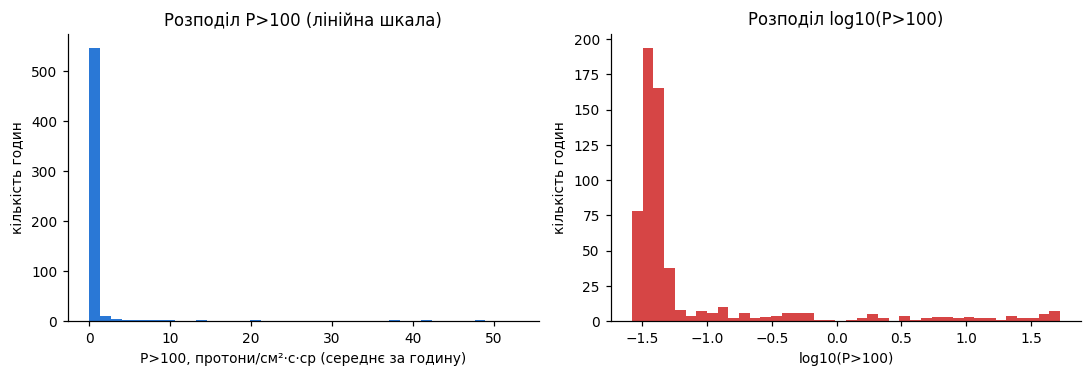

In [19]:
mean_v = M['P>100_mean'].mean()
median_v = M['P>100_mean'].median()
print('середнє: %.3f, медіана: %.3f' % (mean_v, median_v))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].hist(M['P>100_mean'].dropna(), bins=40, color='#2a78d6')
ax[0].set_xlabel('P>100, протони/см²·с·ср (середнє за годину)')
ax[0].set_ylabel('кількість годин')
ax[0].set_title('Розподіл P>100 (лінійна шкала)')

ax[1].hist(np.log10(M['P>100_mean'].dropna().clip(lower=1e-6)), bins=40, color='#d64545')
ax[1].set_xlabel('log10(P>100)')
ax[1].set_ylabel('кількість годин')
ax[1].set_title('Розподіл log10(P>100)')

fig.tight_layout()
plt.show()

**Висновок:**

Розподіл дуже скошений праворуч: медіана (0.039) майже в 42 рази менша за
середнє (1.66), бо кілька годин з дуже сильними сплесками тягнуть середнє вгору, тоді як типова година — майже фонове значення. На лінійній гістограмі майже всі години стискаються в один стовпчик біля нуля; 

після логарифмування розподіл стає читабельним, і видно, що більшість годин
лежить приблизно в діапазоні 0.01–1, а великі значення — рідкісні.

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

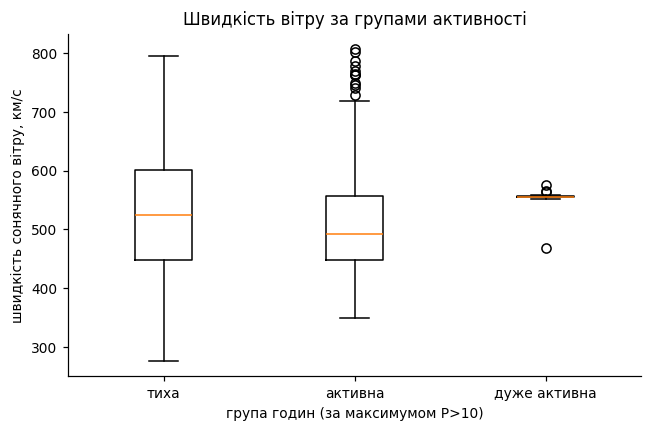

тиха медіана: 524 км/с, n=403
активна медіана: 492 км/с, n=171
дуже активна медіана: 556 км/с, n=18


In [20]:
groups_order = ['тиха', 'активна', 'дуже активна']
data = [M.loc[M['група'] == g, 'швидкість вітру'].dropna() for g in groups_order]

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(data, tick_labels=groups_order)
ax.set_xlabel('група годин (за максимумом P>10)')
ax.set_ylabel('швидкість сонячного вітру, км/с')
ax.set_title('Швидкість вітру за групами активності')
fig.tight_layout()
plt.show()

for g, d in zip(groups_order, data):
    print(g, 'медіана: %.0f км/с, n=%d' % (d.median(), len(d)))

**Висновок:**

Медіана швидкості вітру відрізняється між групами не дуже сильно: 524 км/с
у «тихих» годинах, 492 км/с у «активних», 556 км/с у «дуже активних» (n = 403 / 171 / 18
відповідно).

Висока радіаційна активність (P>10) не гарантує, що сонячний вітер у цей момент буде високошвидкісним. Це два окремі процеси, які можуть відбуватися незалежно один від одного.


### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

коефіцієнт кореляції: 0.285


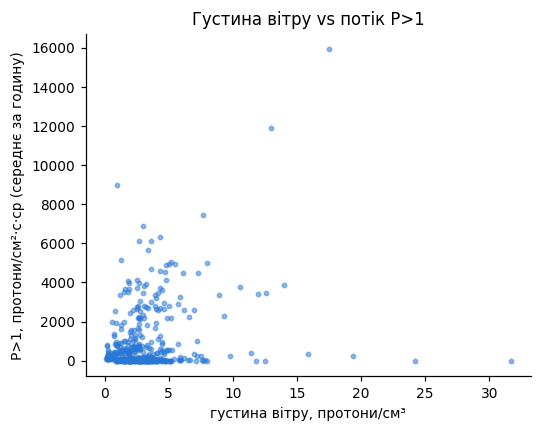

In [21]:
corr = M['густина вітру'].corr(M['P>1_mean'])
print('коефіцієнт кореляції: %.3f' % corr)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(M['густина вітру'], M['P>1_mean'], s=8, alpha=0.5, color='#2a78d6')
ax.set_xlabel('густина вітру, протони/см³')
ax.set_ylabel('P>1, протони/см²·с·ср (середнє за годину)')
ax.set_title('Густина вітру vs потік P>1')
fig.tight_layout()
plt.show()

**Висновок:**

Кореляція слабка (r ≈ 0.285): помітної лінійної залежності між густиною
сонячного вітру і потоком P>1 на діаграмі не видно — точки утворюють широку розсіяну хмару, а не чітку лінію.

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

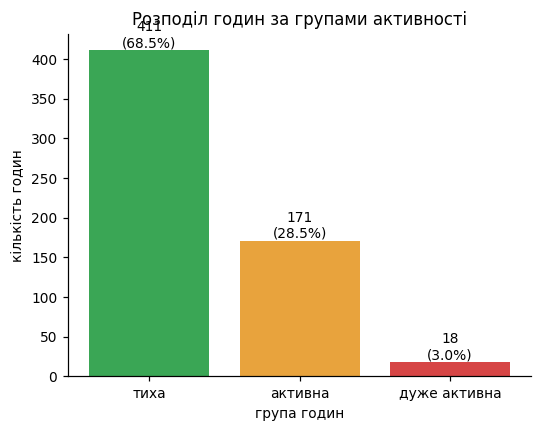

In [22]:
groups_order = ['тиха', 'активна', 'дуже активна']
counts = M['група'].value_counts().reindex(groups_order)
pct = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(groups_order, counts.values, color=['#3aa655', '#e8a33d', '#d64545'])
for bar, cnt, p in zip(bars, counts.values, pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{cnt}\n({p:.1f}%)',
            ha='center', va='bottom')
ax.set_xlabel('група годин')
ax.set_ylabel('кількість годин')
ax.set_title('Розподіл годин за групами активності')
fig.tight_layout()
plt.show()

**Висновок:**

Переважна більшість годин (68.4%, 411 годин) — «тихі», активних — 28.5%
(171 година), і лише 3.0% (18 годин) потрапили в категорію «дуже активна». Тобто більшість часу супутник фіксує стан спокою.

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

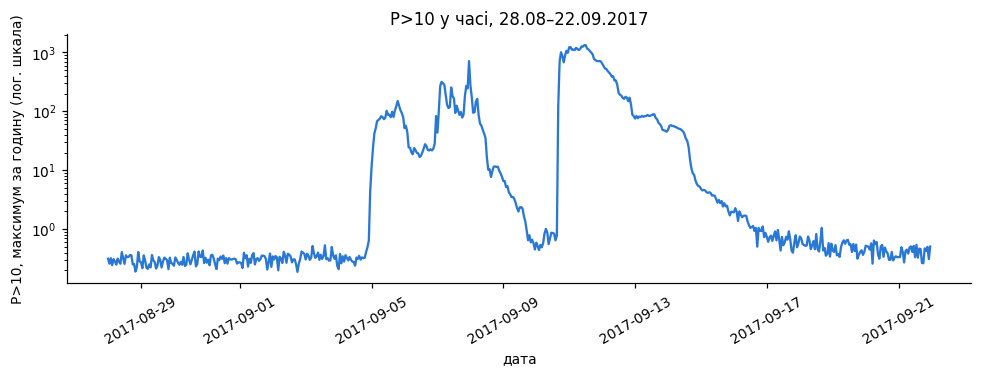

In [23]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(M['ts'], M['P>10_max'], color='#2a78d6')
ax.set_yscale('log')
ax.set_xlabel('дата')
ax.set_ylabel('P>10, максимум за годину (лог. шкала)')
ax.set_title('P>10 у часі, 28.08–22.09.2017')
ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()

**Висновок:**

На логарифмічній шкалі видно, що фонове значення потоку коливається на
кілька порядків, а найпомітніший і найдовший сплеск припадає на період приблизно 6–11 вересня, коли значення зростають у сотні–тисячі разів відносно фону. Поза цим інтервалом активність здебільшого низька й відносно рівномірна.

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

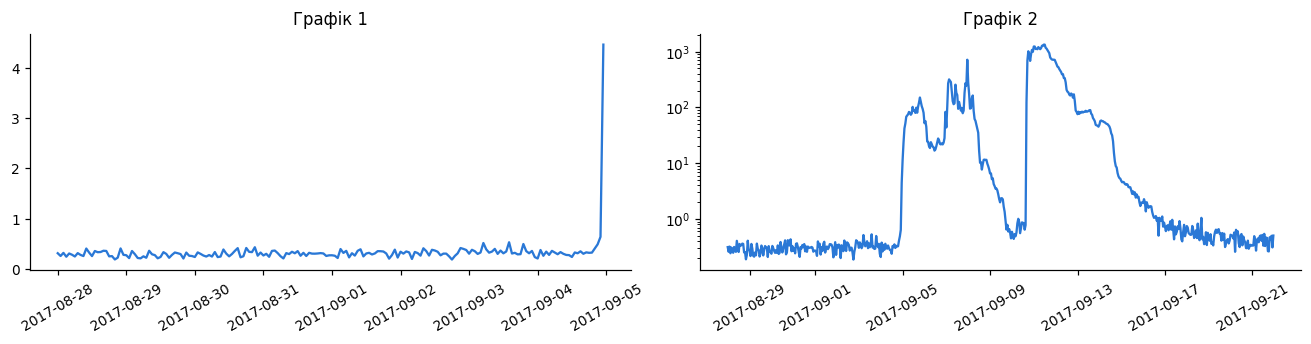

In [24]:
СТОВПЕЦЬ = 'P>10_max'   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка: людина, що бачила тільки Графік 1 (лінійна шкала, лише перший
   тиждень, 28.08–05.09), побачить майже пласку лінію біля нуля з ледь помітними коливаннями і зробить висновок, що космічна погода в цей період спокійна, без значних подій.
2. Висновок з другого графіка: людина, що бачила тільки Графік 2 (логарифмічна шкала, увесь
   період, 28.08–22.09), побачить різкий підйом на кілька порядків на початку вересня і зробить висновок, що стався потужний і, можливо, небезпечний сплеск активності.
3. Дві відмінності: Графік 1 показує лише перший тиждень спостережень, а Графік 2 — увесь період; Графік 1 побудований у лінійній шкалі, а Графік 2 — у логарифмічній, яка стискає великі значення і робить дрібні коливання настільки ж помітними на око, як і великі стрибки.


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

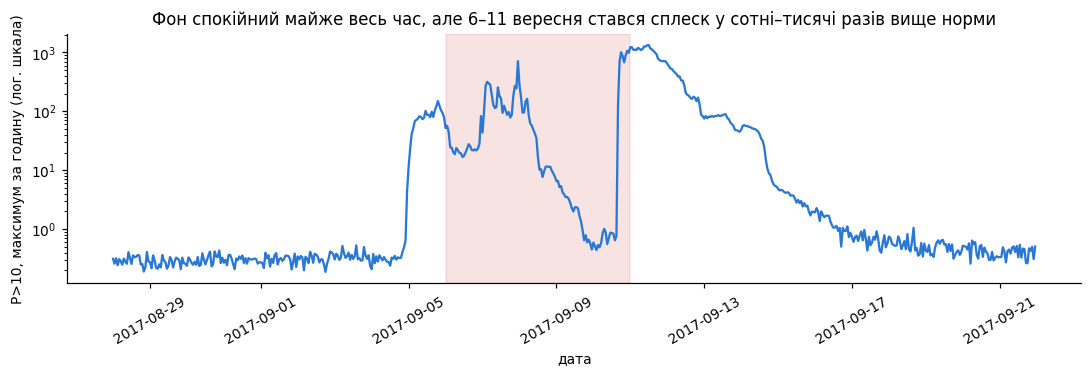

In [25]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax.set_yscale('log')
ax.axvspan(pd.Timestamp('2017-09-06'), pd.Timestamp('2017-09-11'), color='#d64545', alpha=0.15)
ax.set_xlabel('дата')
ax.set_ylabel('P>10, максимум за годину (лог. шкала)')
ax.set_title('Фон спокійний майже весь час, але 6–11 вересня стався сплеск у сотні–тисячі разів вище норми')
ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()

**Відповідь 6.2:** *(чому ви побудували графік саме так)*

Обрано весь період і логарифмічну шкалу — вона одночасно показує і фонові коливання, і рідкісний потужний сплеск.
Заголовок прямо формулює висновок, а не просто описує «що зображено на графіку», а виділена область звертає увагу на найважливіший інтервал.

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:** Розподіл потоку P>100 несиметричний відносно свого середнього значення: середнє за годину (1.66) майже в 42 рази більше за медіану (0.039) — видно на Графіку 1 (Етап 5).

**Спостереження 2:** Найдовша неперервна серія «активних» і «дуже активних» годин поспіль триває 98 годин (майже 4 доби) — обчислено нижче, у Завданні 7.2, на основі стовпця `група` з Етапу 4.4.

**Спостереження 3:** Лише 3.0% годин (18 з 601) потрапили в категорію «дуже активна» (Графік 4),
а день з найбільшим радіопотоком F10.7 (04.09.2017) не збігається з годиною пікового значення
потоку P>100 (10.09.2017, 22:00) — пік радіовипромінювання Сонця і пік потоку заряджених частинок
припали на різні дні цього вікна спостережень.

### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [26]:
num_cols = [c for c in M.columns if M[c].dtype.kind in 'fi' and c not in ('ts',)]
cv = (M[num_cols].std() / M[num_cols].mean()).abs().sort_values(ascending=False)
display(cv)

print('\nнайдовша серія активних+ годин поспіль, год.:')
active = M['група'].isin(['активна', 'дуже активна']).astype(int).values
найдовша = поточна = 0
for v in active:
    if v:
        поточна += 1
        найдовша = max(найдовша, поточна)
    else:
        поточна = 0
print(найдовша)

print('\nнайбільший розкид відносно власного середнього:', cv.index[0], '— CV = %.2f' % cv.iloc[0])

P>100_mean         4.308375
P>100_max          4.223354
P>50_mean          3.842016
P>50_max           3.778265
P>30_mean          3.569527
P>30_max           3.510205
P>10_mean          2.901722
P>10_max           2.826926
P>1_max            2.654705
P>5_mean           2.476875
P>5_max            2.441740
P>1_mean           2.167934
E>2.0_mean         1.474061
E>2.0_max          1.423943
густина вітру      0.883661
E>0.8_mean         0.799040
E>0.8_max          0.759051
F10.7              0.234962
швидкість вітру    0.216257
dtype: float64


найдовша серія активних+ годин поспіль, год.:
98

найбільший розкид відносно власного середнього: P>100_mean — CV = 4.31


**Відповідь 7.2:**

Найбільший розкид відносно власного середнього має стовпець `P>100_mean` (стандартне відхилення понад у 4 рази перевищує середнє). Це узгоджується з Графіком 1: потік частинок високої енергії (P>100) - рідкісна подія, яка більшість часу близька до фонового рівня, але в окремі години зростає на кілька порядків, тому розкид відносно середнього великий.

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [27]:
ІНСТРУМЕНТИ_ШІ = 'Claude (Anthropic)'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'код, перевірено',
    'етап 3, паспорт даних і дивні значення':     'код, перевірено',
    'етап 4, об’єднання таблиць':                 'код, перевірено',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'текст, перероблено',
    'етапи 6–7, порівняння графіків і спостереження': 'текст, перероблено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = (
    'Перейменувала службові змінні на власні (назва/т → name/df, доба → date, \n'
    'потік_максимум/потік_середнє → p_max/p_mean) і прибрала частину коментарів, \nщоб переконатися, '
    'що розумію, що саме робить кожен рядок. \nПеревірила '
    'межі таблиць B–O/Q–T/Y–AF і кількість заповнених клітинок \nчерез RAW.notna().sum()),'
    'переписала відповіді 3.2, 3.3, відповідь 4.3 про вибір \nouter-об’єднання, висновки до графіків 2, 3, 5 і відповіді 6.1–7.2. '
    'Звірила розміри таблиць (A=7200, B=25, C=601, M=601) \nі розподіл груп активності (411/171/18) із '
    'результатами асертів у клітинках самоперевірки.'
)

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [28]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Хвостова Олександра
інструменти:                                   Claude (Anthropic)
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    код, перевірено
етап 3, паспорт даних і дивні значення:        код, перевірено
етап 4, об’єднання таблиць:                    код, перевірено
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                текст, перероблено
етапи 6–7, порівняння графіків і спостереження: текст, перероблено
------------------------------------------------------------------------------
перевірено автором:
Перейменувала службові змінні на власні (назва/т → name/df, доба → date, 
потік_максимум/потік_середнє → p_max/p_mean) і прибрала частину коментарів, 
щоб переконатися, що розумію, що саме робить кожен рядок. 
Перевірила межі таблиць B–O/Q–T/Y–AF і кількість з

---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [29]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (601, 21)


In [30]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
